# TD6 : Introduction à l'Apprentissage machine
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#import sys
#print(sys.executable)

## Exercice 1 - Régression linéaire

1. Représenter graphiquement sous forme de nuage de points l’évolution de la tige de la plante en fonction de la largeur de son tronc

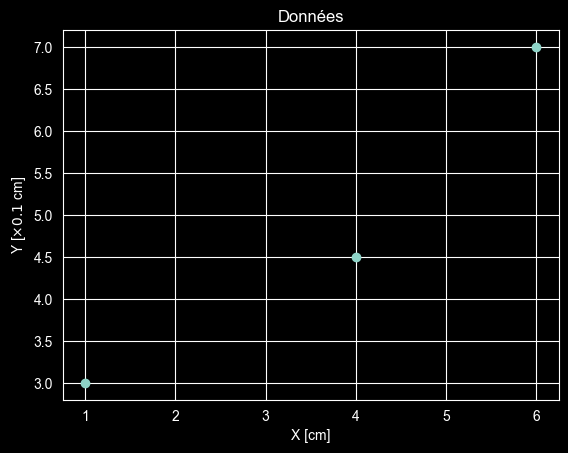

In [36]:
X = np.array([1,4,6], dtype=float)
Y = np.array([3,4.5,7], dtype=float)

plt.figure()
plt.scatter(X, Y)
plt.title("Données")
plt.xlabel("X [cm]")
plt.ylabel(r"Y [$\times 0.1$ cm]")
plt.grid(True)
plt.show()

2. Écrire l’expression de $y = h_\theta(x)$, l’hypothèse décrivant l’évolution de la largeur du tronc
en fonction de la hauteur de la tige.

$$y = \theta_1 x + \theta_0$$

3. Écrire le critère J décrivant l’évolution de la largeur du tronc en fonction de la hauteur de la
tige.

$$J  = \frac{1}{2m} \sum_{i=1}^m \left(h_\theta\left(x^{(i)}\right)-y^{(i)} \right) ^2$$
($m=3$ échantillons)

4. Écrire l’algorithme de descente de gradient pour calculer les paramètres

**Données**

$$\begin{eqnarray*}
\mathbf{x} & = & \left(x^{(1)}, x^{(2)},\dots ,x^{(m)}\right)\\
\mathbf{y} & = & \left(y^{(1)}, y^{(2)}, \dots, y^{(m)} \right)\\
\end{eqnarray*}$$

**Initialisation**

\begin{eqnarray*}
\theta_0 & \leftarrow & 0\\
\theta_1 & \leftarrow & 0\\
\epsilon & \leftarrow & \cdots\\
\end{eqnarray*}

**Entraînement**

faire{
\begin{eqnarray*}
\theta_0 & \leftarrow & \theta_0 - \frac{\alpha}{m}\sum_{i=1}^m \left(h_\theta(x^{(i)})-y^{(i)} \right)\\
\theta_1 & \leftarrow & \theta_1 - \frac{\alpha}{m}\sum_{i=1}^m \left(h_\theta(x^{(i)})-y^{(i)} \right)x^{(i)}\\
J & = & \frac{1}{2m} \sum_{i=1}^m \left(h_\theta(x^{(i)})-y^{(i)} \right) ^2
\end{eqnarray*}
} tant que $(J > \epsilon)$

**Prédiction**

$$\hat{y}  = h_\theta(x)$$

5. Effectuer la descente de gradient sur 4 itérations, avec un pas $\alpha = \frac{1}{40}$.

iteration 1
theta_0 = 0.121, theta_1 = 0.525
J = 13.042

iteration 2
theta_0 = 0.191, theta_1 = 0.807
J = 4.107

iteration 3
theta_0 = 0.233, theta_1 = 0.958
J = 1.508

iteration 4
theta_0 = 0.260, theta_1 = 1.039
J = 0.750

Modèle final
y = 1.039 x + 0.260


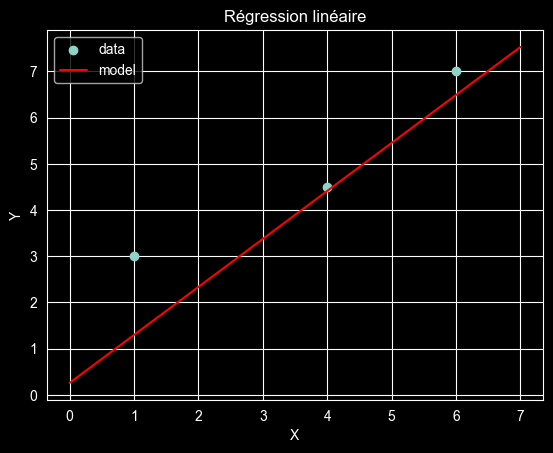

In [37]:
m = len(X)

#Init
theta_0 = 0.0
theta_1 = 0.0
alpha = 0.025
epochs = 4

for epoch in range(epochs):

    Y_hat = theta_1 * X + theta_0
    error = Y_hat - Y

    dtheta_0 = (1/m) * np.sum(error)
    dtheta_1 = (1/m) * np.sum(error * X)

    theta_0 = theta_0 - alpha * dtheta_0
    theta_1 = theta_1 - alpha * dtheta_1

    J = (1/(2*m)) * np.sum(error**2)

    print(f"iteration {epoch+1}")
    print(f"theta_0 = {theta_0:.3f}, theta_1 = {theta_1:.3f}")
    print(f"J = {J:.3f}")
    print()

print("Modèle final")
print(f"y = {theta_1:.3f} x + {theta_0:.3f}")



x_line = np.linspace(min(X)-1, max(X)+1, 100)
y_line = theta_1 * x_line + theta_0

plt.scatter(X, Y, label="data")
plt.plot(x_line, y_line,  color="red", label="model")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Régression linéaire")
plt.show()

6. Des mesures en septembre et en novembre donnent :

| Mois      | $X_i$ | $Y_i$ |
|-----------|-------|-------|
| Septembre | 7 | 8     |
| Novembre  | 5 | 6     |

Effectuer les estimations selon le modèle et calculer les erreurs commises

In [21]:
x_s, x_n = 7, 5
y_s_hat = theta_1 * x_s + theta_0
y_n_hat = theta_1 * x_n + theta_0

print("Prédictions")
print(f"y_sep = {y_s_hat:.2f}")
print(f"y_nov = {y_n_hat:.2f}")



Prédictions
y_sep = 7.53
y_nov = 5.45


## Exercice 2 - Régression logistique


1. Tracer le nuage de points correspondant aux points de mesure

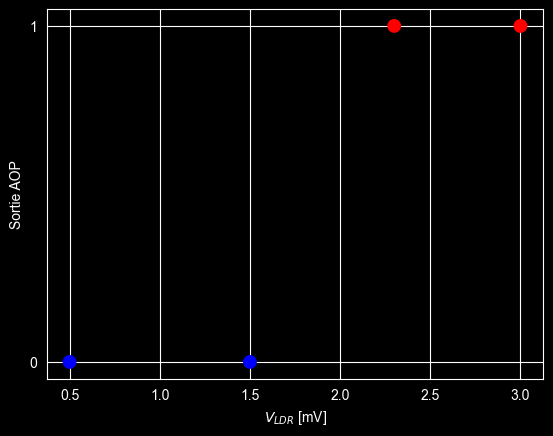

In [77]:
X = np.array([0.5,1.5,2.3,3], dtype=float)
Y = np.array([0,0,1,1], dtype=float)

plt.figure()
plt.scatter(X, Y, c=Y, cmap='bwr', s=80, label="Points")
plt.yticks([0, 1])
plt.xlabel(r"$V_{LDR}$ [mV]")
plt.ylabel("Sortie AOP")
plt.show()

2. Écrire l'expression de la fonction d'hypothèse

$$h_{\mathbf{\theta}}(\mathbf{x})=\sigma(\mathbf{\theta}^{\top}\mathbf{x})=\frac{1}{1+e^{-\mathbf{\theta}^{\top}\mathbf{x}}}$$

3. Comment la régression logistique peut-elle aider à décider du seuil d’éclairage et prédire une
augmentation d’éclairage de la salle ?

4. Donner l’expression du critère J en fonction de l’hypothèse de régression logistique.

$$J  =  \frac{1}{2m} \sum_{i=1}^m \left( \hat{y}^{(i)}-y^{(i)} \right) ^2 = \frac{1}{2m} \sum_{i=1}^m \left(h_{\mathbf{\theta}}(\mathbf{x}^{(i)})-y^{(i)} \right) ^2$$

5. Utiliser une descente de gradient sur 5 itérations et avec un pas de 0.2 pour calculer les paramètres.

La mise à jour des paramètres est donnée par

$$\mathbf{\theta} \leftarrow \mathbf{\theta} - \frac{\alpha}{m} \sum_{i=1}^m \left(h_\theta(x^{(i)})-y^{(i)} \right) h_{\mathbf{\theta}}(\mathbf{x}^{(i)}) \left(1-h_{\mathbf{\theta}}(\mathbf{x}^{(i)})\right) \mathbf{x}^{(i)}$$

Il y a 4 vecteurs de dimension 1



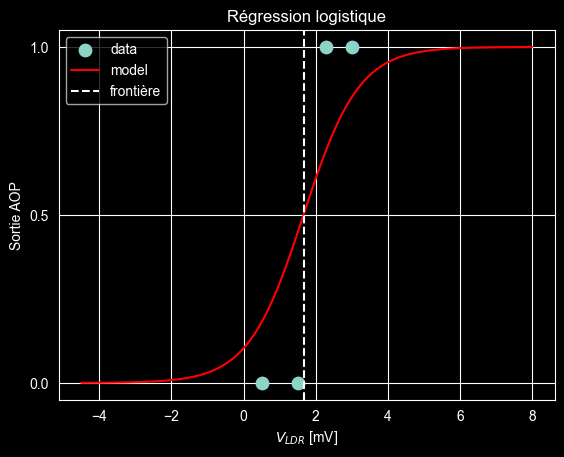

Modèle final
y = sigmoide(-2.164 x + 1.301)
J = 0.043


In [111]:
def sigm(z):
    return 1 / (1 + np.exp(-z))

if X.ndim == 1:
    m = X.shape[0]
    p = 1
else:
    m, p = X.shape

print(f"Il y a {m} vecteurs de dimension {p}\n")

X_aug = np.column_stack((np.ones(m), X))
Yr = Y.reshape(-1,1)

alpha = 0.2
epochs = 500

Theta = np.zeros((p + 1, 1), dtype=float)

for epoch in range(epochs):

    Z = X_aug @ Theta
    H = sigm(Z)
    DH = H*(1-H)
    ERR = H-Yr

    dTheta = 1/m* (X_aug.T) @ (ERR * DH)
    Theta = Theta -alpha * dTheta
    J = (1/(2*m) * (ERR.T @ ERR)).item()

    # print(f"Iteration {epoch + 1}")
    # print("Theta =")
    # print(Theta)
    # print(f"J = {J:.6f}")
    # print()

theta_0 = Theta[0,0]
theta_1 = Theta[1,0]
x_0 = -theta_0/theta_1

x_line = np.linspace(min(X)-5, max(X)+5, 100)
y_line = sigm(theta_1 * x_line + theta_0)

plt.figure()
plt.title("Régression logistique")
plt.scatter(X, Y, s=80, label="data")
plt.plot(x_line, y_line,  color="red", label="model")
plt.axvline(x_0, color='white', linestyle='--', label="frontière")
plt.yticks([0, 0.5, 1])
plt.xlabel(r"$V_{LDR}$ [mV]")
plt.ylabel("Sortie AOP")
plt.legend()
plt.show()

print("Modèle final")
print(f"y = sigmoide({theta_0:.3f} x + {theta_1:.3f})")
print(f"J = {J:.3f}")

## Exercice 3 - SVM


1. Calculer l’hyperplan optimal au sens de la SVM.
2. Calculer la marge maximale nécessaire.
3. Tracer l’hyperplan.

Vecteur w : [1.172, 1.172]
Biais b :-3.400

Frontière :
1.172 x1 + 1.172 x2 + -3.400 = 0

Vecteurs support proches à 0.50 :
[[2. 2.]
 [1. 1.]]


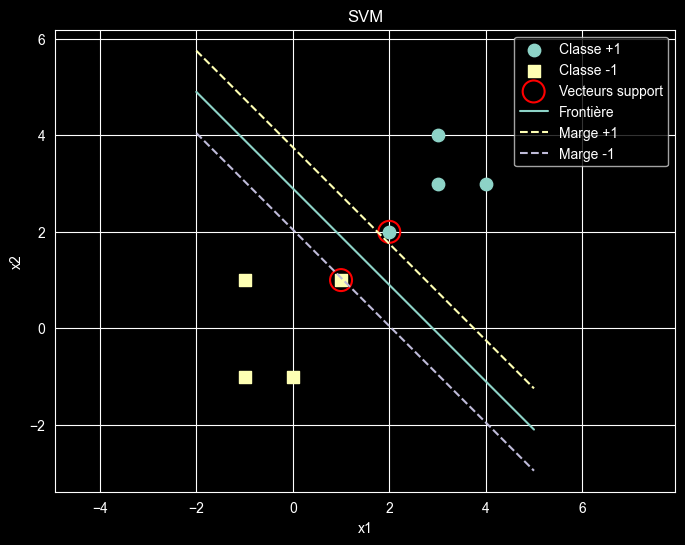

In [145]:
X_pos = np.array([
    [2, 2],
    [3, 3],
    [3, 4],
    [4, 3]
], dtype=float)

X_neg = np.array([
    [1, 1],
    [0, -1],
    [-1, 1],
    [-1, -1]
], dtype=float)

X = np.vstack((X_pos, X_neg))

Y = np.hstack((
    np.ones(len(X_pos)),
    -np.ones(len(X_neg))
))


def hyp(X, w, b):
    return X @ w + b

def hinge(u):
    return np.maximum(0, 1 - u)

def predict(X, w, b):
    return np.where(hyp(X, w, b) >= 0, 1, -1)

m, p = X.shape

w = np.zeros(p, dtype=float)
b = 0.0

alpha = 0.01
epochs = 10000
C = 10.0

for epoch in range(epochs):

    scores = hyp(X, w, b)
    margins = Y * scores
    losses = hinge(margins)

    J = 1/2* (w @ w) + C * np.sum(losses)

    # points actifs
    active = margins < 1

    dw = w - C * (X[active].T @ Y[active])
    db = -C * np.sum(Y[active])
    w -= alpha * dw
    b -= alpha * db

print(f"Vecteur w : [{w[0]:.3f}, {w[1]:.3f}]")
print(f"Biais b :{b:.3f}\n")

print("Frontière :")
print(f"{w[0]:.3f} x1 + {w[1]:.3f} x2 + {b:.3f} = 0")

# Y_pred = predict(X, w, b)
# print("Prédictions :")
# for xi, yi, yhat in zip(X, Y, Y_pred):
#     print(f"x = {xi}, y_vrai = {int(yi)}, y_predit = {int(yhat)}")

# Vecteurs de support approchés

scores = hyp(X, w, b)
margins = Y * scores

tol = 5e-1
support_mask = np.abs(margins - 1) < tol
support_vectors = X[support_mask]

print()
print(f"Vecteurs support proches à {tol:.2f} :")
print(support_vectors)

plt.figure(figsize=(8, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], s=80, marker='o', label='Classe +1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], s=80, marker='s', label='Classe -1')

if len(support_vectors) > 0:
    plt.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=250,
        facecolors='none',
        edgecolors='r',
        linewidths=1.5,
        label='Vecteurs support'
    )

x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 400)

if abs(w[1]) > 1e-12:
    x2_vals = -(w[0] * x1_vals + b) / w[1]
    x2_margin_plus = -(w[0] * x1_vals + b - 1) / w[1]
    x2_margin_minus = -(w[0] * x1_vals + b + 1) / w[1]

    plt.plot(x1_vals, x2_vals, label='Frontière')
    plt.plot(x1_vals, x2_margin_plus, '--', label='Marge +1')
    plt.plot(x1_vals, x2_margin_minus, '--', label='Marge -1')

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVM")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()